# Imports

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
from typing import List
from torch.optim import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import Dataset, random_split, DataLoader

# Globals

In [2]:
device = 'cuda'
seed = 231
torch.manual_seed(42)
np.random.seed(42)

# Dataset

In [3]:
class BostonDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        self.df = pd.read_csv(csv_path).dropna()
        X_df: pd.DataFrame = self.df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']]
        X_np = X_df.to_numpy(np.float32)
        self.X = torch.from_numpy(X_np)
        
        Y_df = self.df[['MEDV']]
        Y_np = Y_df.to_numpy(np.float32)
        self.Y = torch.from_numpy(Y_np)
        
        print(self.X.shape, self.Y.shape)
        
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
    def __len__(self):
        return len(self.X)

In [4]:
dataset = BostonDataset('dataset/HousingData.csv')

torch.Size([394, 13]) torch.Size([394, 1])


In [5]:
train_dataset, test_dataset = random_split(dataset, [0.7, 0.3], generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_dataset, shuffle=True)
test_loader = DataLoader(test_dataset)

# Model

In [6]:
class BostonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 26),
            nn.ReLU(),
            nn.Linear(26, 26),
            nn.ReLU(),
            nn.Linear(26, 1)
        )
        
    def forward(self, x):
        return self.model(x)

# Metrics Calculation

In [7]:
def graph_loss(loss_ot: List[float]):
    plt.plot(range(1, len(loss_ot) + 1), loss_ot, c='blue', label='Loss Over Time')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.grid(True)
    plt.legend()
    plt.show()

In [8]:
def calc_metrics(Y_true: torch.Tensor, Y_pred: torch.Tensor):
    Y_pred_np = Y_pred.detach().cpu().numpy()
    Y_true_np = Y_true.detach().cpu().numpy()
    
    r2 = r2_score(Y_true_np, Y_pred_np)
    
    return r2

# Inference Loop

In [9]:
def run(epochs = 100, lr = 1e-3, print_epochs = False):
    model = BostonModel().to(device)
    optimiser = Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_loss_ot = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", disable=not print_epochs)
        
        for inputs, targets in pbar:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimiser.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            loss.backward()
            optimiser.step()

            total_loss += loss.item()
            
        avg_train_loss = total_loss / len(train_loader)
        train_loss_ot.append(avg_train_loss)
        if print_epochs:
            print(f'Avg Training Loss = {avg_train_loss}')
    
    model.eval()
    return model, train_loss_ot

In [10]:
def test(model):
    preds = []
    targets = []

    with torch.no_grad():
        for X, Y in test_loader:
            X = X.to(device)
            preds.append(model(X).detach().cpu())
            targets.append(Y)

    Y_pred = torch.cat(preds)
    Y_true = torch.cat(targets)
    r2 = calc_metrics(Y_true, Y_pred)
    print(f'r2 score on test dataset = {r2}')

# Testing

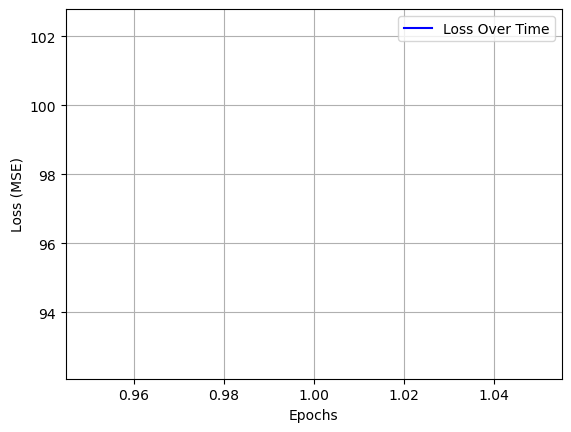

r2 score on test dataset = -0.08851420879364014


In [11]:
model, loss_ot = run(epochs=1)
graph_loss(loss_ot)
test(model)

## 50 Epochs

### 0.1 Learning Rate

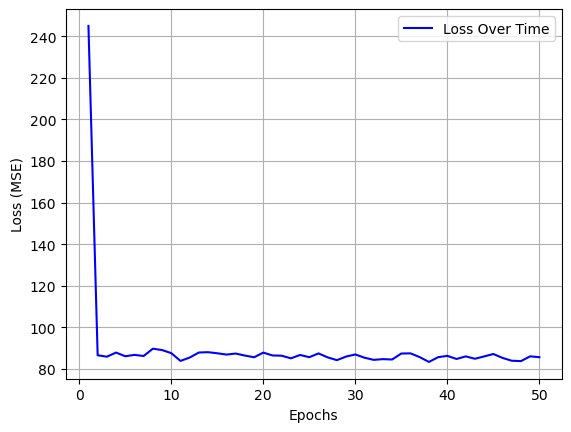

r2 score on test dataset = -0.0012013912200927734


In [12]:
model, loss_ot = run(epochs=50, lr=0.1)
graph_loss(loss_ot)
test(model)

### 0.001 Learning Rate

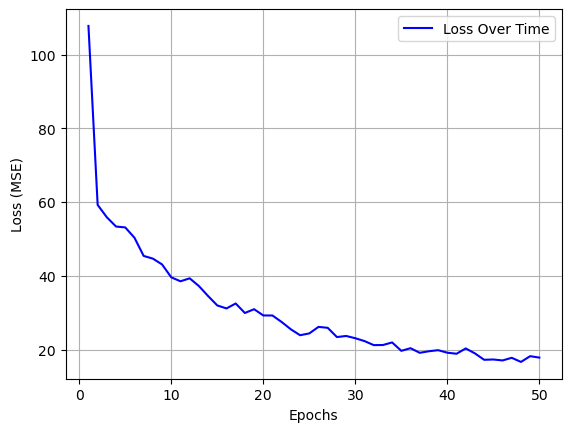

r2 score on test dataset = 0.7013230323791504


In [13]:
model, loss_ot = run(epochs=50, lr=0.001)
graph_loss(loss_ot)
test(model)

### 0.0001 Learning Rate

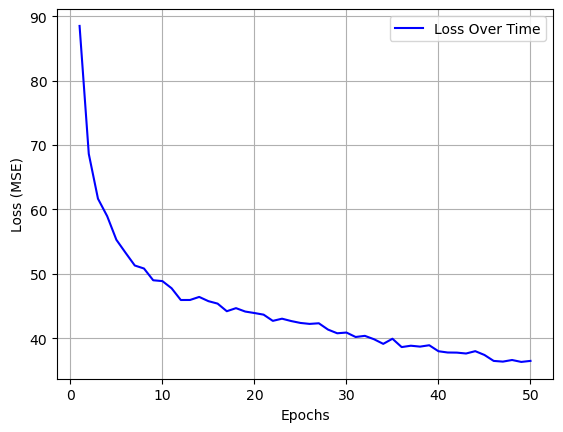

r2 score on test dataset = 0.3884589672088623


In [14]:
model, loss_ot = run(epochs=50, lr=0.0001)
graph_loss(loss_ot)
test(model)

## 100 Epochs

### 0.1 Learning Rate

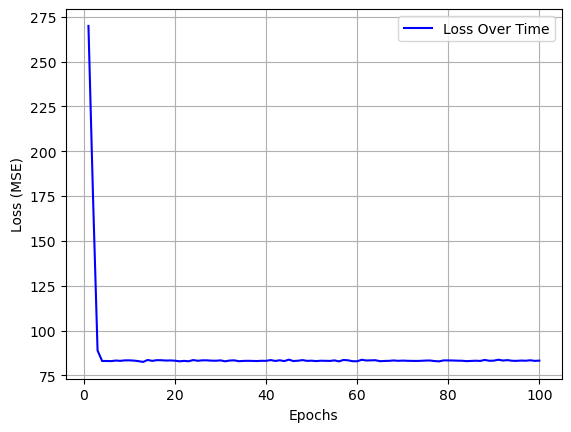

r2 score on test dataset = -0.07969999313354492


In [15]:
model, loss_ot = run(epochs=100, lr=0.1)
graph_loss(loss_ot)
test(model)

### 0.001 Learning Rate

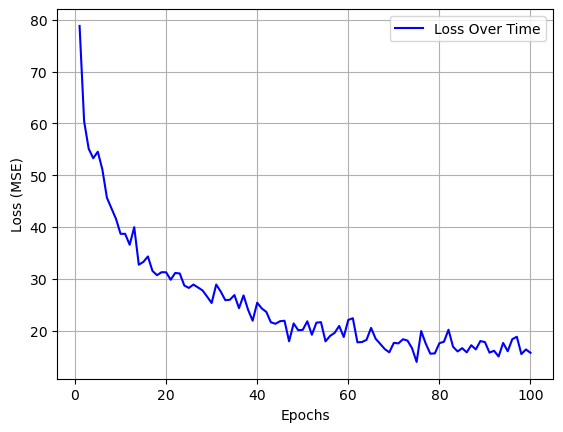

r2 score on test dataset = 0.6904826164245605


In [16]:
model, loss_ot = run(epochs=100, lr=0.001)
graph_loss(loss_ot)
test(model)

### 0.0001 Learning Rate

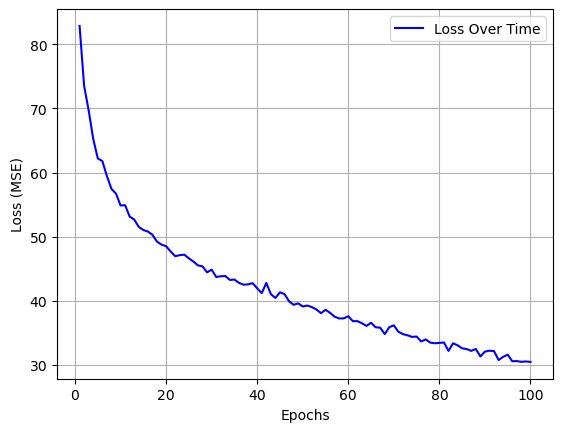

r2 score on test dataset = 0.5016317367553711


In [17]:
model, loss_ot = run(epochs=100, lr=0.0001)
graph_loss(loss_ot)
test(model)

## 500 Epochs

### 0.1 Learning Rate

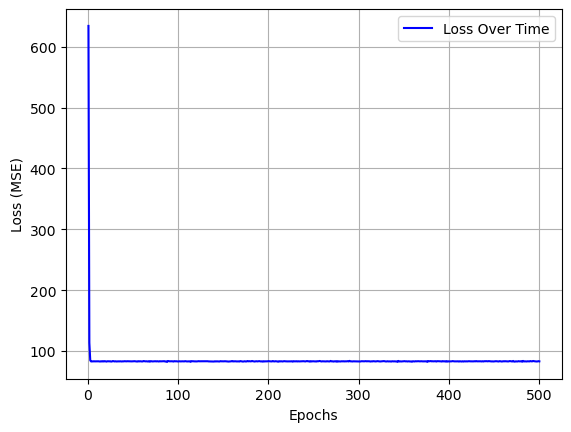

r2 score on test dataset = -0.03933250904083252


In [18]:
model, loss_ot = run(epochs=500, lr=0.1)
graph_loss(loss_ot)
test(model)

### 0.001 Learning Rate

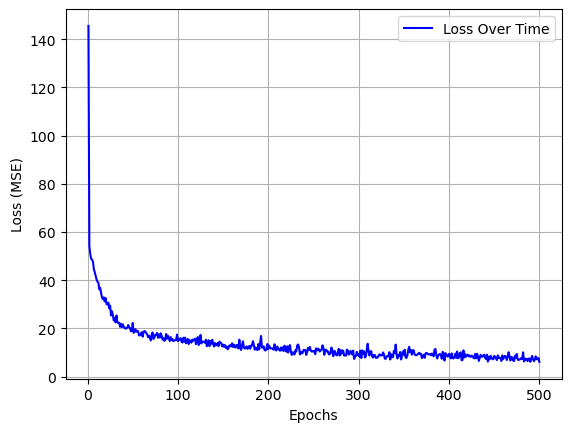

r2 score on test dataset = 0.7132092714309692


In [19]:
model, loss_ot = run(epochs=500, lr=0.001)
graph_loss(loss_ot)
test(model)

### 0.0001 Learning Rate

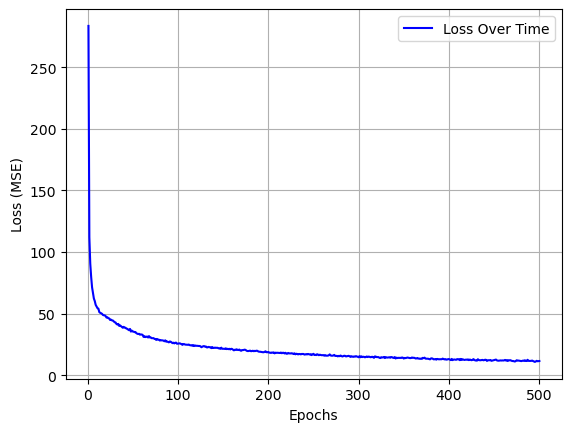

r2 score on test dataset = 0.7296807169914246


In [20]:
model, loss_ot = run(epochs=500, lr=0.0001)
graph_loss(loss_ot)
test(model)

## 1000 Epochs

### 0.1 Learning Rate

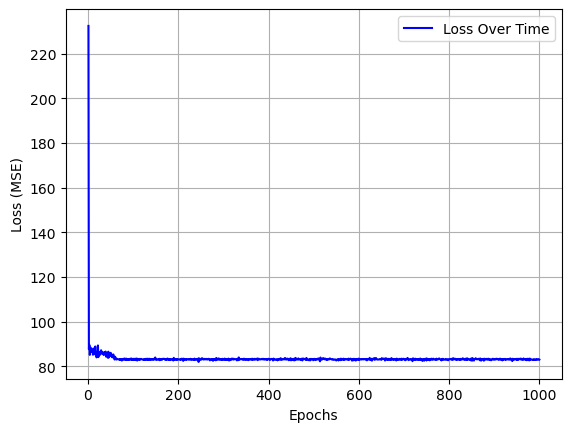

r2 score on test dataset = -0.027294635772705078


In [21]:
model, loss_ot = run(epochs=1000, lr=0.1)
graph_loss(loss_ot)
test(model)

### 0.001 Learning Rate

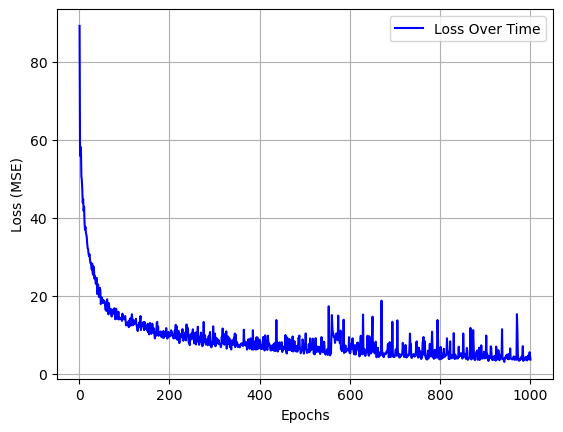

r2 score on test dataset = 0.6880789995193481


In [22]:
model, loss_ot = run(epochs=1000, lr=0.001)
graph_loss(loss_ot)
test(model)

### 0.0001 Learning Rate

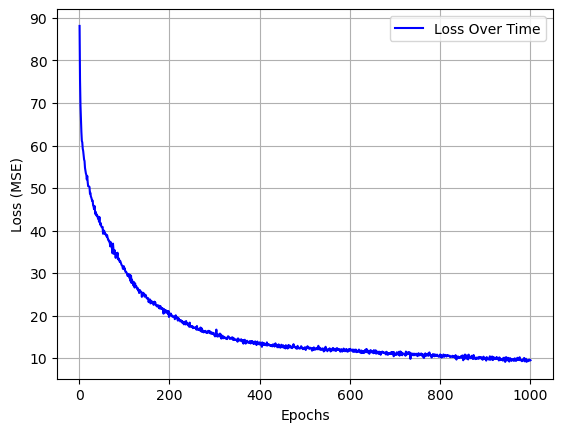

r2 score on test dataset = 0.7063496112823486


In [23]:
model, loss_ot = run(epochs=1000, lr=0.0001)
graph_loss(loss_ot)
test(model)